# NL2P Model Comparison Plot

This notebook compares model-level action/argument extraction results for the
current top-level NL2P result directories:

Bars compare:
- `results/nl2p_1`
- `results/nl2p_1_ablation`
- `results/nl2p_1_coref`

Horizontal dashed lines show the NLP baselines:
- `cEASDRL`
- `cEASDRL*`

In [146]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "results").exists() and (path / "src").exists():
            return path
    raise RuntimeError("Could not find repo root with results/ and src/.")


ROOT = find_repo_root()
RESULT_ROOT = ROOT / "results"

DOMAIN_LABELS = {
    "win2k": "WHS",
    "cooking": "CT",
    "wikihow": "WHG",
}
DOMAINS = ["WHS", "CT", "WHG"]

MODEL_ORDER = [
    "gemma3-12b",
    "gemma3-27b",
    "llama3-70b",
    "gpt-5.4",
    "gpt-5.4-mini",
]
MODEL_LABELS = {
    "gemma3_12b": "Gemma3-12B",
    "gemma3-12b": "Gemma3-12B",
    "gemma3-27b": "Gemma3-27B",
    "gemma3": "Gemma3",
    "gpt-4.1": "GPT-4.1",
    "gpt-4.1-mini": "GPT-4.1-mini",
    "gpt-4o": "GPT-4o",
    "gpt-4o-mini": "GPT-4o-mini",
    "gpt-5.4": "GPT-5.4",
    "gpt-5.4-mini": "GPT-5.4-mini",
    "llama3-70b": "Llama3.3-70B",
}

STRATEGY_MODEL_ORDER = MODEL_ORDER

STRATEGIES = {
    "nl2p_1": "NL2P-1",
    "nl2p_1_ablation": "Ablation",
    "nl2p_1_coref": "Coref",
}

METRIC_LABELS = {
    "F1": "Action F1",
    "Object F1": "Argument F1",
}

extra_data = [
    ["WHS", "cEASDRL", "none", 0.9275, 0.925],
    ["CT", "cEASDRL", "none", 0.852, 0.765],
    ["WHG", "cEASDRL", "none", 0.7843, 0.771],
    ["WHS", "cEASDRL*", "none", 0.8393, 0.8008],
    ["CT", "cEASDRL*", "none", 0.7883, 0.665],
    ["WHG", "cEASDRL*", "none", 0.7174, 0.686],
]

## Load Top-level Strategy Results

The notebook reads `evaluation_result.csv` from the top-level strategy
directories under `results/`. It uses the result directory name as the model
identity so old CSV solver/model quirks do not leak into plots.

In [147]:
def load_strategy_results(strategy_key, strategy_label):
    rows = []
    strategy_root = RESULT_ROOT / strategy_key
    if not strategy_root.exists():
        print(f"Missing result directory: {strategy_root}")
        return pd.DataFrame()

    for model_dir in sorted(p for p in strategy_root.iterdir() if p.is_dir()):
        csv_path = model_dir / "evaluation_result.csv"
        if not csv_path.exists():
            continue

        df = pd.read_csv(csv_path)
        for _, row in df.iterrows():
            dataset = str(row["dataset"]).strip()
            domain = DOMAIN_LABELS.get(dataset)
            if domain is None:
                continue
            rows.append(
                {
                    "domain": domain,
                    "strategy_key": strategy_key,
                    "method": strategy_label,
                    "strategy": strategy_label,
                    "model": model_dir.name,
                    "model_label": MODEL_LABELS.get(model_dir.name, model_dir.name),
                    "Action Precision": float(row["Precision"]),
                    "Action Recall": float(row["Recall"]),
                    "Action F1": float(row["F1"]),
                    "Argument Precision": float(row["Object Precision"]),
                    "Argument Recall": float(row["Object Recall"]),
                    "Argument F1": float(row["Object F1"]),
                }
            )
    return pd.DataFrame(rows)


result_df = pd.concat(
    [
        load_strategy_results(strategy_key, strategy_label)
        for strategy_key, strategy_label in STRATEGIES.items()
    ],
    ignore_index=True,
)

missing_models = [model for model in MODEL_ORDER if model not in set(result_df["model"])]
if missing_models:
    print("Models missing from at least one result directory:", missing_models)

result_df = result_df[result_df["model"].isin(MODEL_ORDER)].copy()
result_df["model"] = pd.Categorical(result_df["model"], MODEL_ORDER, ordered=True)
result_df["domain"] = pd.Categorical(result_df["domain"], DOMAINS, ordered=True)
result_df = result_df.sort_values(["domain", "model", "method"]).reset_index(drop=True)

baseline_df = pd.DataFrame(
    extra_data,
    columns=["domain", "method", "model", "Action F1", "Argument F1"],
)

display(result_df.head(5))
display(baseline_df)

,domain,strategy_key,method,strategy,model,model_label,Action Precision,Action Recall,Action F1,Argument Precision,Argument Recall,Argument F1
0,WHS,nl2p_1_ablation,Ablation,Ablation,gemma3-12b,Gemma3-12B,0.953450,0.857891,0.903150,0.796596,0.541353,0.644628
1,WHS,nl2p_1_coref,Coref,Coref,gemma3-12b,Gemma3-12B,0.970213,0.852655,0.907643,0.767540,0.528522,0.625991
2,WHS,nl2p_1,NL2P-1,NL2P-1,gemma3-12b,Gemma3-12B,0.961083,0.849663,0.901945,0.770921,0.533022,0.630270
3,WHS,nl2p_1_ablation,Ablation,Ablation,gemma3-27b,Gemma3-27B,0.942387,0.857036,0.897687,0.804089,0.538813,0.645249
4,WHS,nl2p_1_coref,Coref,Coref,gemma3-27b,Gemma3-27B,0.958621,0.834209,0.892098,0.818834,0.539598,0.650517


,domain,method,model,Action F1,Argument F1
0,WHS,cEASDRL,none,0.9275,0.9250
1,CT,cEASDRL,none,0.8520,0.7650
2,WHG,cEASDRL,none,0.7843,0.7710
3,WHS,cEASDRL*,none,0.8393,0.8008
4,CT,cEASDRL*,none,0.7883,0.6650
5,WHG,cEASDRL*,none,0.7174,0.6860


## Figure-style Comparison

Top row: action-name F1. Bottom row: argument-name F1. Each column is one
dataset. Bars compare the three top-level NL2P strategies. Dashed horizontal
baselines are repeated within each dataset panel.

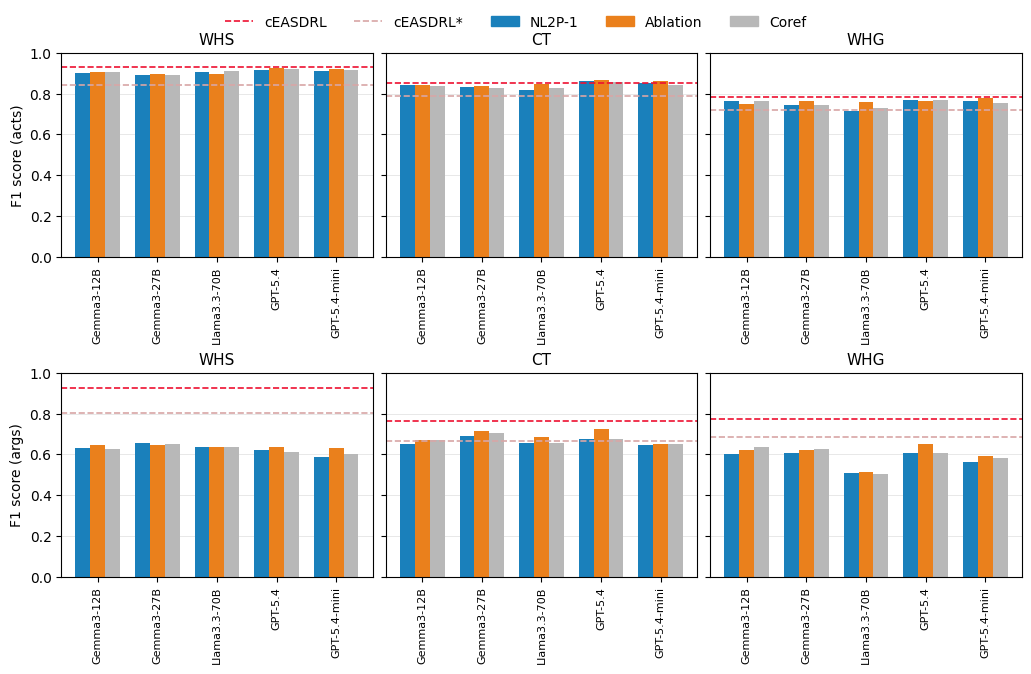

In [206]:
def plot_model_comparison(result_df, baseline_df):
    colors = {
        "NL2P-1": "#1a80bb",
        "Ablation": "#ea801c",
        "Coref": "#b8b8b8",
    }

    baseline_styles = {
        "cEASDRL": {"color": "#ed1131", "linestyle": "--", "linewidth": 1.2},
        "cEASDRL*": {"color": "#d8a6a6", "linestyle": "--", "linewidth": 1.2},
    }

    metrics = ["Action F1", "Argument F1"]
    methods = ["NL2P-1", "Ablation", "Coref"]
    models = [m for m in MODEL_ORDER if m in set(result_df["model"].astype(str))]
    model_labels = [MODEL_LABELS.get(m, m) for m in models]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(10.2, 6.4),
        sharey="row",
        constrained_layout=True,
    )

    x = np.arange(len(models))
    width = 0.25
    offsets = {
        "NL2P-1": -width,
        "Ablation": 0.0,
        "Coref": width,
    }

    for row_idx, metric in enumerate(metrics):
        for col_idx, domain in enumerate(DOMAINS):
            ax = axes[row_idx, col_idx]
            panel = result_df[result_df["domain"].astype(str) == domain]

            for method in methods:
                values = []
                for model in models:
                    match = panel[
                        (panel["method"] == method)
                        & (panel["model"].astype(str) == model)
                    ]
                    values.append(np.nan if match.empty else match.iloc[0][metric])

                ax.bar(
                    x + offsets[method],
                    values,
                    width=width,
                    label=method,
                    color=colors[method],
                    edgecolor="none",
                )

            base_panel = baseline_df[baseline_df["domain"] == domain]
            for baseline_name, style in baseline_styles.items():
                match = base_panel[base_panel["method"] == baseline_name]
                if not match.empty:
                    ax.axhline(float(match.iloc[0][metric]), **style, label=baseline_name)

            ax.set_title(domain, fontsize=11)
            ax.set_ylim(0.0, 1.0)
            ax.set_xticks(x)
            ax.set_xticklabels(model_labels, rotation=90, fontsize=8)
            ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
            ax.set_axisbelow(True)
            if col_idx == 0:
                ax.set_ylabel(f"F1 score ({'acts' if row_idx == 0 else 'args'})")

    legend_handles = [
        plt.Line2D([0], [0], color="#ed1131", linestyle="--", linewidth=1.2, label="cEASDRL"),
        plt.Line2D([0], [0], color="#d8a6a6", linestyle="--", linewidth=1.2, label="cEASDRL*"),
        plt.Rectangle((0, 0), 1, 1, color=colors["NL2P-1"], label="NL2P-1"),
        plt.Rectangle((0, 0), 1, 1, color=colors["Ablation"], label="Ablation"),
        plt.Rectangle((0, 0), 1, 1, color=colors["Coref"], label="Coref"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=5,
        frameon=False,
    )
    return fig


fig = plot_model_comparison(result_df, baseline_df)
plt.show()

## Paper Table

This table is convenient when drafting the caption or checking exact values.

In [149]:
table_df = result_df.pivot_table(
    index=["method", "model_label"],
    columns="domain",
    values=["Action F1", "Argument F1"],
    aggfunc="first",
    observed=False,
)

baseline_table = baseline_df.assign(model_label="baseline").pivot_table(
    index=["method", "model_label"],
    columns="domain",
    values=["Action F1", "Argument F1"],
    aggfunc="first",
    observed=False,
)

display(pd.concat([baseline_table, table_df]).round(4))

Action F1                 Argument F1                
domain                       CT     WHG     WHS          CT     WHG     WHS
method   model_label                                                       
cEASDRL  baseline        0.8520  0.7843  0.9275      0.7650  0.7710  0.9250
cEASDRL* baseline        0.7883  0.7174  0.8393      0.6650  0.6860  0.8008
Ablation GPT-5.4         0.8682  0.7647  0.9244      0.7261  0.6501  0.6347
         GPT-5.4-mini    0.8628  0.7772  0.9215      0.6525  0.5917  0.6316
         Gemma3-12B      0.8407  0.7485  0.9031      0.6703  0.6235  0.6446
         Gemma3-27B      0.8384  0.7639  0.8977      0.7155  0.6235  0.6452
         Llama3.3-70B    0.8475  0.7600  0.8976      0.6827  0.5113  0.6341
Coref    GPT-5.4         0.8568  0.7706  0.9215      0.6745  0.6073  0.6134
         GPT-5.4-mini    0.8423  0.7555  0.9153      0.6530  0.5817  0.6010
         Gemma3-12B      0.8373  0.7641  0.9076      0.6724  0.6369  0.6260
         Gemma3-27B      0.8290  0.7425  0.8921      0.7047  0.6244  0.6505
         Llama3.3-70B    0.8268  0.7286  0.9079      0.6563  0.5025  0.6346
NL2P-1   GPT-5.4         0.8611  0.7661  0.9169      0.6756  0.6090  0.6220
         GPT-5.4-mini    0.8528  0.7628  0.9101      0.6472  0.5621  0.5891
         Gemma3-12B      0.8418  0.7638  0.9019      0.6516  0.6010  0.6303
         Gemma3-27B      0.8297  0.7437  0.8917      0.6901  0.6052  0.6537
         Llama3.3-70B    0.8190  0.7130  0.9040      0.6579  0.5090  0.6380

## Argument Precision and Recall

This figure follows the compact precision/recall style: each model has one bar
per dataset. Orange shows recall; blue shows the part of precision that is above
recall. The top of the bar is therefore the larger of precision and recall.

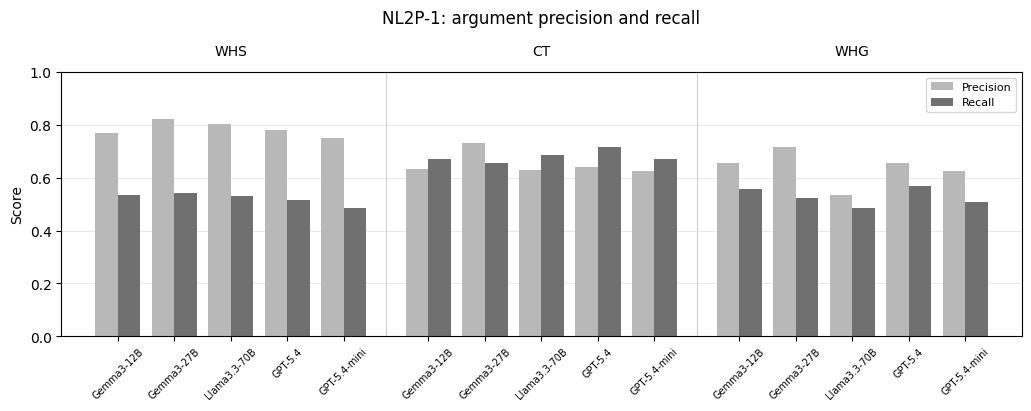

In [210]:
def plot_precision_recall_by_domain(result_df, method="NL2P-1", metric_prefix="Argument"):
    panel_df = result_df[result_df["method"] == method].copy()
    models = [model for model in MODEL_ORDER if model in set(panel_df["model"].astype(str))]
    model_labels = [MODEL_LABELS.get(model, model) for model in models]

    fig, ax = plt.subplots(figsize=(10.2, 4), constrained_layout=True)
    bar_width = 0.4            # each individual bar width
    model_spacing = 2 * bar_width + 0.2 # distance between model centers
    domain_gap = 0.5           # extra gap between domain groups
    half = bar_width / 2       # offset for side-by-side
    
    x_positions = []
    x_labels = []
    domain_centers = []
    precision_values = []
    recall_values = []

    for domain_idx, domain in enumerate(DOMAINS):
        base_x = domain_idx * (len(models) + domain_gap)
        domain_positions = []
        for model_idx, model in enumerate(models):
            x = base_x + model_idx
            domain_positions.append(x)
            x_positions.append(x)
            x_labels.append(model_labels[model_idx])

            match = panel_df[
                (panel_df["domain"].astype(str) == domain)
                & (panel_df["model"].astype(str) == model)
            ]
            if match.empty:
                precision_values.append(np.nan)
                recall_values.append(np.nan)
            else:
                precision_values.append(float(match.iloc[0][f"{metric_prefix} Precision"]))
                recall_values.append(float(match.iloc[0][f"{metric_prefix} Recall"]))
        domain_centers.append(np.mean(domain_positions))

    precision_values = np.array(precision_values, dtype=float)
    recall_values = np.array(recall_values, dtype=float)

    # Precision bar — shifted left
    ax.bar(
        [xp - half for xp in x_positions],
        precision_values,
        width=bar_width,
        color="#b8b8b8",
        edgecolor="none",
        label="Precision",
    )

    # Recall bar — shifted right
    ax.bar(
        [xp + half for xp in x_positions],
        recall_values,
        width=bar_width,
        color="#707070",
        edgecolor="none",
        label="Recall",
    )

    for center, domain in zip(domain_centers, DOMAINS):
        ax.text(center, 1.05, domain, ha="center", va="bottom", fontsize=10)

    for boundary_idx in range(1, len(DOMAINS)):
        last_of_prev = (boundary_idx - 1) * (len(models) * model_spacing + domain_gap) + (len(models) - 1) * model_spacing
        first_of_next = boundary_idx * (len(models) * model_spacing + domain_gap)
        boundary = (last_of_prev + first_of_next) / 2
        ax.axvline(boundary, color="#cfcfcf", linewidth=0.8)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, fontsize=7)
    ax.set_ylabel("Score")
    ax.set_ylim(0.0, 1.0)

    # Tighten left/right margins
    ax.set_xlim(x_positions[0] - 1, x_positions[-1] + 1)

    ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc="upper right", frameon=True, fontsize=8)
    ax.set_title(
        f"{method}: {metric_prefix.lower()} precision and recall",
        pad=35)
    return fig


fig = plot_precision_recall_by_domain(result_df, method="NL2P-1", metric_prefix="Argument")
plt.show()

## Strategy Delta vs NL2P-1

This section uses the current top-level result directories rather than the older
`results/experiment/` runs. Each delta is computed within the same
`model + dataset` pair:

`delta = strategy F1 - nl2p_1 F1`

Positive bars mean the strategy improved over the original NL2P-1 prompt.

In [151]:
strategy_df = result_df.copy()
strategy_df = strategy_df[strategy_df["model"].isin(STRATEGY_MODEL_ORDER)].copy()
strategy_df["model"] = pd.Categorical(
    strategy_df["model"], STRATEGY_MODEL_ORDER, ordered=True
)
strategy_df["domain"] = pd.Categorical(strategy_df["domain"], DOMAINS, ordered=True)
strategy_df = strategy_df.sort_values(["domain", "model", "strategy_key"]).reset_index(
    drop=True
)

baseline_strategy = strategy_df[strategy_df["strategy_key"] == "nl2p_1"][
    ["domain", "model", "Action F1", "Argument F1"]
].rename(
    columns={
        "Action F1": "Action F1 baseline",
        "Argument F1": "Argument F1 baseline",
    }
)

strategy_delta_df = strategy_df[strategy_df["strategy_key"] != "nl2p_1"].merge(
    baseline_strategy,
    on=["domain", "model"],
    how="inner",
)
strategy_delta_df["Action F1 delta"] = (
    strategy_delta_df["Action F1"] - strategy_delta_df["Action F1 baseline"]
)
strategy_delta_df["Argument F1 delta"] = (
    strategy_delta_df["Argument F1"] - strategy_delta_df["Argument F1 baseline"]
)

display(strategy_delta_df.head(5))

,domain,strategy_key,method,strategy,model,model_label,Action Precision,Action Recall,Action F1,Argument Precision,Argument Recall,Argument F1,Action F1 baseline,Argument F1 baseline,Action F1 delta,Argument F1 delta
0,WHS,nl2p_1_ablation,Ablation,Ablation,gemma3-12b,Gemma3-12B,0.953450,0.857891,0.903150,0.796596,0.541353,0.644628,0.901945,0.630270,0.001204,0.014359
1,WHS,nl2p_1_coref,Coref,Coref,gemma3-12b,Gemma3-12B,0.970213,0.852655,0.907643,0.767540,0.528522,0.625991,0.901945,0.630270,0.005698,-0.004278
2,WHS,nl2p_1_ablation,Ablation,Ablation,gemma3-27b,Gemma3-27B,0.942387,0.857036,0.897687,0.804089,0.538813,0.645249,0.891720,0.653655,0.005967,-0.008406
3,WHS,nl2p_1_coref,Coref,Coref,gemma3-27b,Gemma3-27B,0.958621,0.834209,0.892098,0.818834,0.539598,0.650517,0.891720,0.653655,0.000378,-0.003139
4,WHS,nl2p_1_ablation,Ablation,Ablation,llama3-70b,Llama3.3-70B,0.947587,0.852545,0.897557,0.803540,0.523645,0.634078,0.904022,0.637955,-0.006465,-0.003877


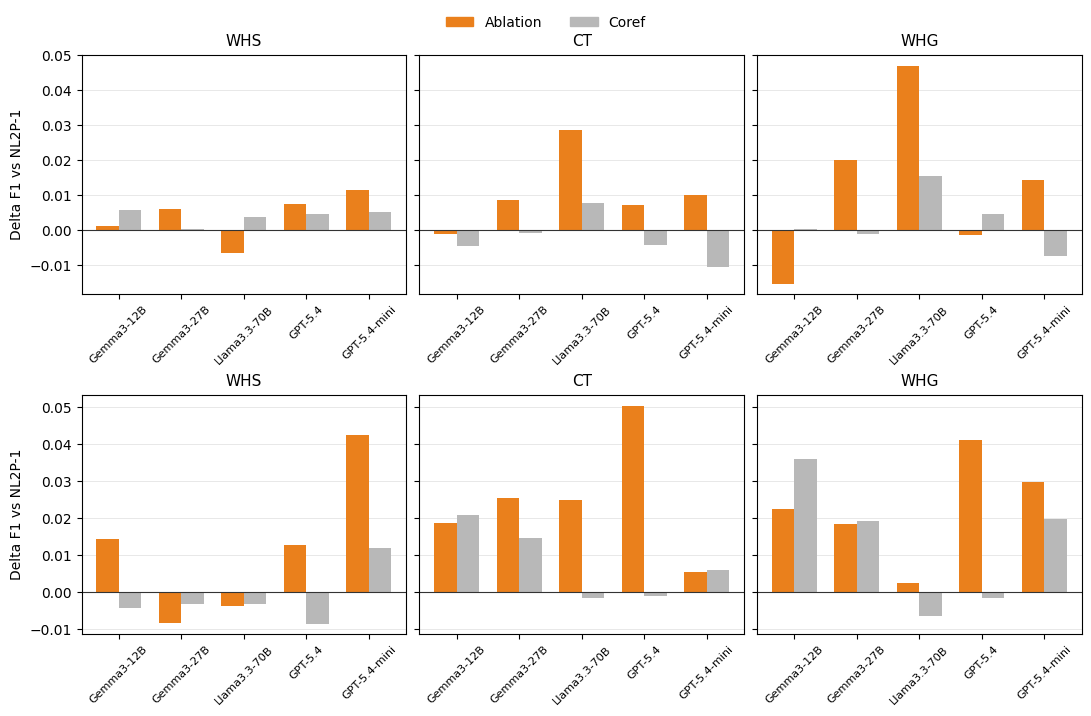

In [207]:
def plot_strategy_delta(strategy_delta_df):
    colors = {
        "Ablation": "#ea801c",
        "Coref": "#b8b8b8",
    }
    metrics = ["Action F1 delta", "Argument F1 delta"]
    strategies = ["Ablation", "Coref"]
    models = [
        model
        for model in STRATEGY_MODEL_ORDER
        if model in set(strategy_delta_df["model"].astype(str))
    ]
    model_labels = [MODEL_LABELS.get(model, model) for model in models]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(10.8, 6.8),
        sharey="row",
        constrained_layout=True,
    )

    x = np.arange(len(models))
    width = 0.36
    offsets = {
        "Ablation": -width / 2,
        "Coref": width / 2,
    }

    for row_idx, metric in enumerate(metrics):
        for col_idx, domain in enumerate(DOMAINS):
            ax = axes[row_idx, col_idx]
            panel = strategy_delta_df[strategy_delta_df["domain"].astype(str) == domain]

            for strategy in strategies:
                values = []
                for model in models:
                    match = panel[
                        (panel["strategy"] == strategy)
                        & (panel["model"].astype(str) == model)
                    ]
                    values.append(np.nan if match.empty else match.iloc[0][metric])

                ax.bar(
                    x + offsets[strategy],
                    values,
                    width=width,
                    color=colors[strategy],
                    label=strategy,
                    edgecolor="none",
                )

            ax.axhline(0.0, color="#333333", linewidth=0.8)
            ax.set_title(domain, fontsize=11)
            ax.set_xticks(x)
            ax.set_xticklabels(model_labels, rotation=45, fontsize=8)
            ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
            ax.set_axisbelow(True)
            if col_idx == 0:
                ax.set_ylabel("Delta F1 vs NL2P-1")

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors["Ablation"], label="Ablation"),
        plt.Rectangle((0, 0), 1, 1, color=colors["Coref"], label="Coref"),
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=2,
        frameon=False,
    )
    return fig


fig = plot_strategy_delta(strategy_delta_df)
plt.show()

In [153]:
delta_table = strategy_delta_df.pivot_table(
    index=["strategy", "model_label"],
    columns="domain",
    values=["Action F1 delta", "Argument F1 delta"],
    aggfunc="first",
    observed=False,
)
display(delta_table.round(4))

Action F1 delta                 Argument F1 delta  \
domain                            WHS      CT     WHG               WHS   
strategy model_label                                                      
Ablation GPT-5.4               0.0075  0.0071 -0.0013            0.0127   
         GPT-5.4-mini          0.0114  0.0100  0.0145            0.0426   
         Gemma3-12B            0.0012 -0.0011 -0.0153            0.0144   
         Gemma3-27B            0.0060  0.0086  0.0202           -0.0084   
         Llama3.3-70B         -0.0065  0.0285  0.0470           -0.0039   
Coref    GPT-5.4               0.0046 -0.0043  0.0046           -0.0085   
         GPT-5.4-mini          0.0052 -0.0104 -0.0073            0.0120   
         Gemma3-12B            0.0057 -0.0045  0.0003           -0.0043   
         Gemma3-27B            0.0004 -0.0008 -0.0013           -0.0031   
         Llama3.3-70B          0.0038  0.0078  0.0156           -0.0034   

                                       
domain                     CT     WHG  
strategy model_label                   
Ablation GPT-5.4       0.0505  0.0411  
         GPT-5.4-mini  0.0053  0.0297  
         Gemma3-12B    0.0187  0.0225  
         Gemma3-27B    0.0254  0.0183  
         Llama3.3-70B  0.0248  0.0024  
Coref    GPT-5.4      -0.0011 -0.0016  
         GPT-5.4-mini  0.0058  0.0197  
         Gemma3-12B    0.0208  0.0360  
         Gemma3-27B    0.0146  0.0191  
         Llama3.3-70B -0.0016 -0.0065

## Diagnostics: Argument Error Composition

This section reads `evaluation_mismatch_diagnostics.csv` from the same
top-level strategy directories. The denominator is all `argument_mismatch` rows
for the same `domain + model + strategy`.

Two high-signal diagnostic families are shown:
- split head/modifier words: `unnecessary_head_or_modifier_split`
- preposition arguments: `preposition_object` or `preposition_argument`

In [163]:
DIAGNOSTIC_ISSUES = {
    "Split head/modifier": ["unnecessary_head_or_modifier_split"],
    "Preposition arg": ["preposition_object", "preposition_argument"],
}


def load_strategy_diagnostics(strategy_key, strategy_label):
    rows = []
    strategy_root = RESULT_ROOT / strategy_key
    if not strategy_root.exists():
        print(f"Missing strategy directory: {strategy_root}")
        return pd.DataFrame()

    for model_dir in sorted(p for p in strategy_root.iterdir() if p.is_dir()):
        csv_path = model_dir / "evaluation_mismatch_diagnostics.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df = df[df["mismatch_type"] == "argument_mismatch"].copy()
        if df.empty:
            continue

        for _, row in df.iterrows():
            dataset = str(row["dataset"]).strip()
            domain = DOMAIN_LABELS.get(dataset)
            if domain is None:
                continue

            issue_text = "|".join(
                str(row.get(column, ""))
                for column in [
                    "strong_dataset_issue",
                    "candidate_dataset_issue",
                    "candidate_llm_issue",
                ]
                if pd.notna(row.get(column, ""))
            )
            rows.append(
                {
                    "domain": domain,
                    "strategy_key": strategy_key,
                    "strategy": strategy_label,
                    "model": model_dir.name,
                    "model_label": MODEL_LABELS.get(model_dir.name, model_dir.name),
                    "issue_text": issue_text,
                }
            )
    return pd.DataFrame(rows)


diagnostics_df = pd.concat(
    [
        load_strategy_diagnostics(strategy_key, strategy_label)
        for strategy_key, strategy_label in STRATEGIES.items()
    ],
    ignore_index=True,
)

diagnostics_df = diagnostics_df[
    diagnostics_df["model"].isin(STRATEGY_MODEL_ORDER)
].copy()
diagnostics_df["model"] = pd.Categorical(
    diagnostics_df["model"], STRATEGY_MODEL_ORDER, ordered=True
)
diagnostics_df["domain"] = pd.Categorical(
    diagnostics_df["domain"], DOMAINS, ordered=True
)

diag_rows = []
group_cols = ["domain", "strategy", "model", "model_label"]
for group_values, group in diagnostics_df.groupby(group_cols, observed=True):
    domain, strategy, model, model_label = group_values
    arg_errors = len(group)
    issue_text = group["issue_text"].fillna("")
    for issue_label, needles in DIAGNOSTIC_ISSUES.items():
        count = issue_text.str.contains("|".join(needles), regex=True).sum()
        diag_rows.append(
            {
                "domain": domain,
                "strategy": strategy,
                "model": model,
                "model_label": model_label,
                "issue": issue_label,
                "count": int(count),
                "arg_errors": int(arg_errors),
                "share": count / arg_errors if arg_errors else np.nan,
            }
        )

diag_issue_share_df = pd.DataFrame(diag_rows).sort_values(
    ["issue", "domain", "model", "strategy"]
)
display(diag_issue_share_df.head(5))

,domain,strategy,model,model_label,issue,count,arg_errors,share
31,CT,Ablation,gemma3-12b,Gemma3-12B,Preposition arg,357,1053,0.339031
41,CT,Coref,gemma3-12b,Gemma3-12B,Preposition arg,443,1099,0.403094
51,CT,NL2P-1,gemma3-12b,Gemma3-12B,Preposition arg,417,1101,0.378747
33,CT,Ablation,gemma3-27b,Gemma3-27B,Preposition arg,184,839,0.219309
43,CT,Coref,gemma3-27b,Gemma3-27B,Preposition arg,296,874,0.338673


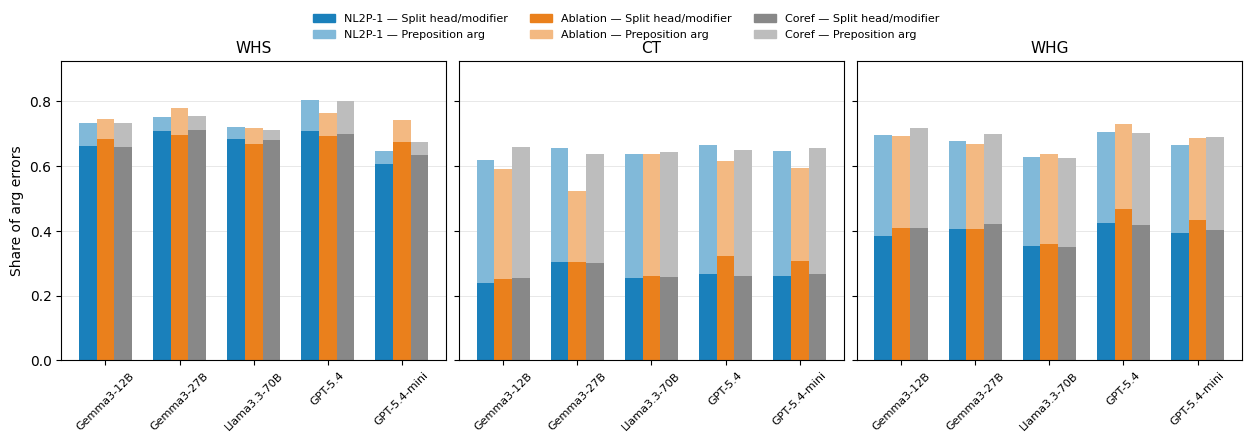

In [203]:
def plot_diagnostic_issue_shares_stacked(diag_issue_share_df):
        strategies = ["NL2P-1", "Ablation", "Coref"]
        issues = list(DIAGNOSTIC_ISSUES)  # bottom issue first, then top

        # Strategy base colors
        bar_colors = {
            "NL2P-1": "#1a80bb",
            "Ablation": "#ea801c",
            "Coref": "#888888",
        }

        def lighten(hex_color, factor=0.45):
            """Blend a hex color toward white."""
            r, g, b = (int(hex_color[i:i+2], 16) for i in (1, 3, 5))
            r = int(r + (255 - r) * factor)
            g = int(g + (255 - g) * factor)
            b = int(b + (255 - b) * factor)
            return f"#{r:02x}{g:02x}{b:02x}"

        # Bottom issue = full color, top issue = lightened
        issue_shade = {issues[0]: lambda c: c, issues[1]: lambda c: lighten(c)}
        models = [
            m for m in STRATEGY_MODEL_ORDER
            if m in set(diag_issue_share_df["model"].astype(str))
        ]
        model_labels = [MODEL_LABELS.get(m, m) for m in models]

        fig, axes = plt.subplots(
            nrows=1, ncols=len(DOMAINS),
            figsize=(12.4, 4.0), sharey=True, constrained_layout=True,
        )

        x = np.arange(len(models))
        width = 0.24
        offsets = {"NL2P-1": -width, "Ablation": 0.0, "Coref": width}

        for col_idx, domain in enumerate(DOMAINS):
            ax = axes[col_idx]
            for strategy in strategies:
                bottom = np.zeros(len(models))
                for issue in issues:
                    panel = diag_issue_share_df[
                        (diag_issue_share_df["issue"] == issue)
                        & (diag_issue_share_df["domain"].astype(str) == domain)
                    ]
                    values = []
                    for model in models:
                        match = panel[
                            (panel["strategy"] == strategy)
                            & (panel["model"].astype(str) == model)
                        ]
                        values.append(
                            0.0 if match.empty else float(match.iloc[0]["share"])
                        )
                    values = np.array(values)
                    color = issue_shade[issue](bar_colors[strategy])
                    ax.bar(
                        x + offsets[strategy], values,
                        bottom=bottom, width=width,
                        color=color, edgecolor="none",
                    )
                    bottom += values

            ax.set_title(domain, fontsize=11)
            ax.set_xticks(x)
            ax.set_xticklabels(model_labels, rotation=45, fontsize=8)
            y_max = max(0.25, diag_issue_share_df.groupby(
                ["domain", "strategy", "model"], observed=True
            )["share"].sum().max() * 1.15)
            ax.set_ylim(0.0, y_max)
            ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
            ax.set_axisbelow(True)
            if col_idx == 0:
                ax.set_ylabel("Share of arg errors")

        # --- Legend: strategy (by hue) + issue (by shade) ---
        legend_handles = []
        # Outer loop = columns (strategies)
        for strategy in strategies:
            # Inner loop = rows (issues)
            for issue in issues:
                color = issue_shade[issue](bar_colors[strategy])
                legend_handles.append(
                    plt.Rectangle((0, 0), 1, 1,
                                   color=color,
                                   label=f"{strategy} — {issue}")
                )

        fig.legend(
            handles=legend_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.08),
            ncol=3,           # 3 columns (strategies)
            frameon=False,
            fontsize=8,
        )
        return fig

fig = plot_diagnostic_issue_shares_stacked(diag_issue_share_df)
plt.show()

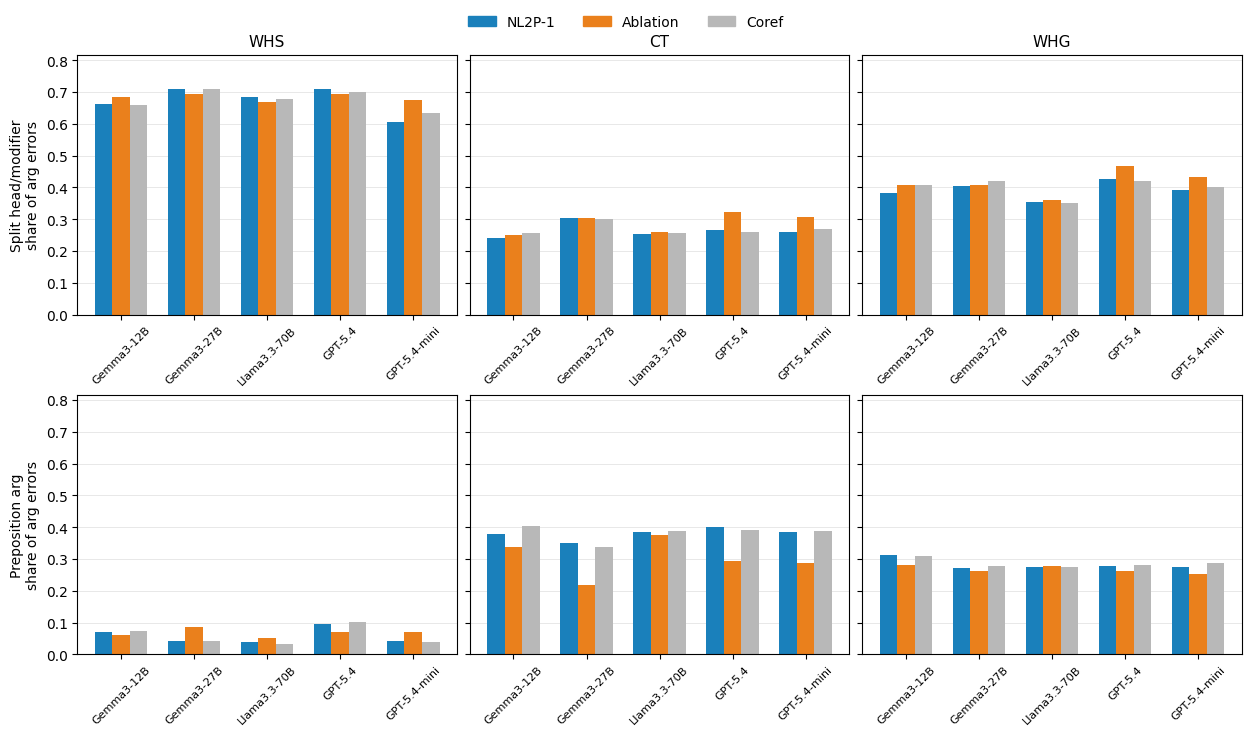

In [208]:
def plot_diagnostic_issue_shares(diag_issue_share_df):
    colors = {
        "NL2P-1": "#1a80bb",
        "Ablation": "#ea801c",
        "Coref": "#b8b8b8",
    }
    strategies = ["NL2P-1", "Ablation", "Coref"]
    issues = list(DIAGNOSTIC_ISSUES)
    models = [
        model
        for model in STRATEGY_MODEL_ORDER
        if model in set(diag_issue_share_df["model"].astype(str))
    ]
    model_labels = [MODEL_LABELS.get(model, model) for model in models]

    fig, axes = plt.subplots(
        nrows=len(issues),
        ncols=len(DOMAINS),
        figsize=(12.4, 7.0),
        sharey="row",
        constrained_layout=True,
    )
    if len(issues) == 1:
        axes = np.array([axes])

    x = np.arange(len(models))
    width = 0.24
    offsets = {
        "NL2P-1": -width,
        "Ablation": 0.0,
        "Coref": width,
    }

    for row_idx, issue in enumerate(issues):
        for col_idx, domain in enumerate(DOMAINS):
            ax = axes[row_idx, col_idx]
            panel = diag_issue_share_df[
                (diag_issue_share_df["issue"] == issue)
                & (diag_issue_share_df["domain"].astype(str) == domain)
            ]
            for strategy in strategies:
                values = []
                for model in models:
                    match = panel[
                        (panel["strategy"] == strategy)
                        & (panel["model"].astype(str) == model)
                    ]
                    values.append(np.nan if match.empty else match.iloc[0]["share"])

                ax.bar(
                    x + offsets[strategy],
                    values,
                    width=width,
                    color=colors[strategy],
                    label=strategy,
                    edgecolor="none",
                )

            ax.set_title(domain if row_idx == 0 else "", fontsize=11)
            ax.set_xticks(x)
            ax.set_xticklabels(model_labels, rotation=45, fontsize=8)
            ax.set_ylim(0.0, max(0.25, diag_issue_share_df["share"].max() * 1.15))
            ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
            ax.set_axisbelow(True)
            if col_idx == 0:
                ax.set_ylabel(f"{issue}\nshare of arg errors")

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors[strategy], label=strategy)
        for strategy in strategies
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=3,
        frameon=False,
    )
    return fig


fig = plot_diagnostic_issue_shares(diag_issue_share_df)
plt.show()

In [165]:
diag_issue_table = diag_issue_share_df.pivot_table(
    index=["issue", "strategy", "model_label"],
    columns="domain",
    values="share",
    aggfunc="first",
    observed=False,
)
display((diag_issue_table * 100).round(2))

domain                                        CT    WHG    WHS
issue               strategy model_label                      
Preposition arg     Ablation GPT-5.4       29.24  26.30   7.12
                             GPT-5.4-mini  28.72  25.22   7.03
                             Gemma3-12B    33.90  28.26   6.11
                             Gemma3-27B    21.93  26.28   8.55
                             Llama3.3-70B  37.56  27.78   5.07
                    Coref    GPT-5.4       38.98  28.25  10.23
                             GPT-5.4-mini  38.81  28.70   3.98
                             Gemma3-12B    40.31  30.96   7.23
                             Gemma3-27B    33.87  27.83   4.29
                             Llama3.3-70B  38.78  27.48   3.34
                    NL2P-1   GPT-5.4       39.96  27.93   9.69
                             GPT-5.4-mini  38.50  27.35   4.17
                             Gemma3-12B    37.87  31.30   7.15
                             Gemma3-27B    35.18  27.27   4.28
                             Llama3.3-70B  38.47  27.36   3.81
Split head/modifier Ablation GPT-5.4       32.31  46.63  69.32
                             GPT-5.4-mini  30.56  43.36  67.35
                             Gemma3-12B    25.07  40.91  68.50
                             Gemma3-27B    30.39  40.66  69.52
                             Llama3.3-70B  26.14  36.02  66.77
                    Coref    GPT-5.4       26.01  41.90  69.89
                             GPT-5.4-mini  26.78  40.23  63.44
                             Gemma3-12B    25.57  40.88  66.00
                             Gemma3-27B    29.98  42.03  71.07
                             Llama3.3-70B  25.63  35.08  67.93
                    NL2P-1   GPT-5.4       26.70  42.60  70.80
                             GPT-5.4-mini  26.06  39.27  60.64
                             Gemma3-12B    23.98  38.32  66.10
                             Gemma3-27B    30.32  40.54  70.84
                             Llama3.3-70B  25.36  35.37  68.29

# Percentage of error in all results